# Target별 VLE 학습행동 EDA

## 분석 목적

- 이탈자와 비이탈자의 주차별 학습활동 차이를 확인한다.
- 클릭 수, 활동일, 이용 콘텐츠 수, 활동 유형 차이를 분석한다.
- 모델 후보 시점인 1주차, 2주차, 4주차 Feature를 준비한다.
- 활동 기록이 없는 학생·주차는 0으로 처리한다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"

COHORT_PATH = (
    INTERIM_DIR
    / "student_registration_merged_corrected.csv"
)

VLE_WEEKLY_PATH = (
    INTERIM_DIR
    / "vle_weekly_features.csv"
)

VLE_PRE_PATH = (
    INTERIM_DIR
    / "vle_pre_course_features.csv"
)

for path in [
    COHORT_PATH,
    VLE_WEEKLY_PATH,
    VLE_PRE_PATH
]:
    print(path.name, ":", path.exists())

student_registration_merged_corrected.csv : True
vle_weekly_features.csv : True
vle_pre_course_features.csv : True


In [2]:
cohort = pd.read_csv(
    COHORT_PATH,
    na_values=["?"]
)

vle_weekly = pd.read_csv(
    VLE_WEEKLY_PATH
)

vle_pre = pd.read_csv(
    VLE_PRE_PATH
)

print("학생-강좌 데이터:", cohort.shape)
print("VLE 주차별 데이터:", vle_weekly.shape)
print("개강 전 VLE 데이터:", vle_pre.shape)

print(
    "학생-강좌 키 중복:",
    cohort.duplicated(
        [
            "code_module",
            "code_presentation",
            "id_student"
        ]
    ).sum()
)

print(
    "VLE 주차별 키 중복:",
    vle_weekly.duplicated(
        [
            "code_module",
            "code_presentation",
            "id_student",
            "week_index"
        ]
    ).sum()
)

학생-강좌 데이터: (32593, 23)
VLE 주차별 데이터: (579438, 16)
개강 전 VLE 데이터: (23809, 5)
학생-강좌 키 중복: 0
VLE 주차별 키 중복: 0


In [4]:
COHORT_KEYS = [
    "code_module",
    "code_presentation",
    "id_student"
]

WEEKLY_KEYS = COHORT_KEYS + ["week_index"]

# 전체 학생-강좌 명단
cohort_keys = cohort[COHORT_KEYS].drop_duplicates()

# 개강 후 VLE 기록이 있는 학생-강좌
post_vle_keys = (
    vle_weekly[COHORT_KEYS]
    .drop_duplicates()
)

# 개강 전 VLE 기록이 있는 학생-강좌
pre_vle_keys = (
    vle_pre[COHORT_KEYS]
    .drop_duplicates()
)

# 전체 명단에 활동 여부 연결
vle_coverage = cohort_keys.merge(
    post_vle_keys.assign(has_post_vle=1),
    on=COHORT_KEYS,
    how="left",
    validate="one_to_one"
)

vle_coverage["has_post_vle"] = (
    vle_coverage["has_post_vle"]
    .fillna(0)
    .astype(int)
)

print("전체 학생-강좌:", len(cohort_keys))
print("개강 후 VLE 있음:", vle_coverage["has_post_vle"].sum())
print("개강 후 VLE 없음:", (vle_coverage["has_post_vle"] == 0).sum())

print(
    "개강 전 VLE 있음:",
    len(pre_vle_keys)
)

print(
    "개강 전 VLE 없음:",
    len(cohort_keys) - len(pre_vle_keys)
)

unmatched_post_vle = post_vle_keys.merge(
    cohort_keys,
    on=COHORT_KEYS,
    how="left",
    indicator=True
)

unmatched_pre_vle = pre_vle_keys.merge(
    cohort_keys,
    on=COHORT_KEYS,
    how="left",
    indicator=True
)

print(
    "전체 명단에 없는 개강 후 VLE:",
    (unmatched_post_vle["_merge"] == "left_only").sum()
)

print(
    "전체 명단에 없는 개강 전 VLE:",
    (unmatched_pre_vle["_merge"] == "left_only").sum()
)



전체 학생-강좌: 32593
개강 후 VLE 있음: 28500
개강 후 VLE 없음: 4093
개강 전 VLE 있음: 23809
개강 전 VLE 없음: 8784
전체 명단에 없는 개강 후 VLE: 0
전체 명단에 없는 개강 전 VLE: 0


In [5]:
CANDIDATE_WEEKS = [1, 2, 4]
MAX_CANDIDATE_WEEK = max(CANDIDATE_WEEKS)

# 학생·강좌별 Target과 등록 정보
cohort_base = cohort[
    COHORT_KEYS + [
        "target",
        "final_result",
        "date_registration",
        "date_unregistration"
    ]
].copy()

cohort_base["date_registration"] = pd.to_numeric(
    cohort_base["date_registration"],
    errors="coerce"
)

cohort_base["date_unregistration"] = pd.to_numeric(
    cohort_base["date_unregistration"],
    errors="coerce"
)

# 1~4주차 표
week_table = pd.DataFrame({
    "week_index": range(1, MAX_CANDIDATE_WEEK + 1)
})

# 전체 학생·강좌 × 1~4주차
student_week_grid = cohort_base.merge(
    week_table,
    how="cross"
)

print("VLE 연결 전 행 수:", len(student_week_grid))
print(
    "예상 행 수:",
    len(cohort_base) * MAX_CANDIDATE_WEEK
)

VLE 연결 전 행 수: 130372
예상 행 수: 130372


In [6]:
VLE_FEATURE_COLUMNS = [
    column
    for column in vle_weekly.columns
    if column not in WEEKLY_KEYS
]

student_week_grid = student_week_grid.merge(
    vle_weekly,
    on=WEEKLY_KEYS,
    how="left",
    validate="one_to_one",
    indicator=True
)

# 실제 VLE 기록 존재 여부
student_week_grid["has_vle_record"] = (
    student_week_grid["_merge"] == "both"
).astype(int)

student_week_grid = student_week_grid.drop(
    columns="_merge"
)

# 활동 기록이 없는 학생·주차는 0
student_week_grid[VLE_FEATURE_COLUMNS] = (
    student_week_grid[VLE_FEATURE_COLUMNS]
    .fillna(0)
)

print("최종 학생-주차 행 수:", len(student_week_grid))
print(
    "학생-강좌-주차 키 중복:",
    student_week_grid.duplicated(WEEKLY_KEYS).sum()
)
print(
    "VLE Feature 전체 결측치:",
    student_week_grid[VLE_FEATURE_COLUMNS].isna().sum().sum()
)

print(
    "VLE 기록이 없는 학생-주차:",
    (student_week_grid["has_vle_record"] == 0).sum()
)

최종 학생-주차 행 수: 130372
학생-강좌-주차 키 중복: 0
VLE Feature 전체 결측치: 0
VLE 기록이 없는 학생-주차: 37589


In [7]:
source_clicks_1_to_4 = (
    vle_weekly.loc[
        vle_weekly["week_index"].between(
            1,
            MAX_CANDIDATE_WEEK
        ),
        "total_clicks"
    ].sum()
)

grid_clicks_1_to_4 = (
    student_week_grid["total_clicks"].sum()
)

print("원본 1~4주차 클릭 합계:", source_clicks_1_to_4)
print("Grid 1~4주차 클릭 합계:", grid_clicks_1_to_4)
print(
    "클릭 합계 일치:",
    source_clicks_1_to_4 == grid_clicks_1_to_4
)

원본 1~4주차 클릭 합계: 7781403
Grid 1~4주차 클릭 합계: 7781403.0
클릭 합계 일치: True


In [8]:
COURSES_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "courses.csv"
)

courses = pd.read_csv(COURSES_PATH)

course_info = courses[
    [
        "code_module",
        "code_presentation",
        "module_presentation_length"
    ]
].drop_duplicates()

# 반복 실행에 대비
student_week_grid = student_week_grid.drop(
    columns="module_presentation_length",
    errors="ignore"
)

student_week_grid = student_week_grid.merge(
    course_info,
    on=[
        "code_module",
        "code_presentation"
    ],
    how="left",
    validate="many_to_one"
)

print(
    "강좌 기간 연결 실패:",
    student_week_grid[
        "module_presentation_length"
    ].isna().sum()
)

강좌 기간 연결 실패: 0


In [9]:
# 각 주차 마지막 날
# 1주차 종료 = 6일, 2주차 종료 = 13일
student_week_grid["cutoff_day"] = (
    student_week_grid["week_index"] * 7 - 1
)

# 등록일이 없는 45건은 개강일 등록으로 가정
student_week_grid["registration_day_for_model"] = (
    student_week_grid["date_registration"]
    .fillna(0)
)

# 이탈 시점이 정상적으로 확인되는 Target
valid_target_timing = (
    student_week_grid["target"].eq(0)
    |
    (
        student_week_grid["target"].eq(1)
        & student_week_grid["date_unregistration"].notna()
        & student_week_grid["date_unregistration"].ge(0)
        & (
            student_week_grid["date_unregistration"]
            < student_week_grid[
                "module_presentation_length"
            ]
        )
    )
)

# 해당 주차 종료일까지 등록된 학생
registered_by_cutoff = (
    student_week_grid["registration_day_for_model"]
    <= student_week_grid["cutoff_day"]
)

# 해당 주차 종료 시점에 아직 이탈하지 않은 학생
still_active_at_cutoff = (
    student_week_grid["target"].eq(0)
    |
    (
        student_week_grid["date_unregistration"]
        > student_week_grid["cutoff_day"]
    )
)

eligible_grid = student_week_grid.loc[
    valid_target_timing
    & registered_by_cutoff
    & still_active_at_cutoff
].copy()

eligible_grid["target_label"] = (
    eligible_grid["target"]
    .map({
        0: "Non-withdrawn",
        1: "Future withdrawn"
    })
)

print(
    "이탈 시점 문제로 제외된 학생-강좌:",
    len(
        student_week_grid.loc[
            student_week_grid["target"].eq(1)
            & ~valid_target_timing,
            COHORT_KEYS
        ].drop_duplicates()
    )
)

print("\n주차 종료 시점별 예측 대상:")
display(
    eligible_grid
    .groupby(
        ["week_index", "target_label"]
    )
    .size()
    .unstack(fill_value=0)
)

이탈 시점 문제로 제외된 학생-강좌: 2770

주차 종료 시점별 예측 대상:


target_label,Future withdrawn,Non-withdrawn
week_index,,
1,6652,22366
2,5589,22395
3,5383,22418
4,5025,22424


===== Target별 주차 VLE 행동 요약 =====


,week_index,target_label,student_course_count,median_total_clicks,mean_total_clicks,median_active_days,median_unique_sites,no_activity_rate_pct
0,1,Future withdrawn,6652,18.0,50.33,2.0,5.0,27.24
1,1,Non-withdrawn,22366,37.0,74.27,2.0,8.0,17.61
2,2,Future withdrawn,5589,19.0,48.98,2.0,5.0,24.89
3,2,Non-withdrawn,22395,32.0,66.66,2.0,7.0,18.39
4,3,Future withdrawn,5383,36.0,70.10,2.0,6.0,20.92
5,3,Non-withdrawn,22418,46.0,84.39,3.0,8.0,15.46
6,4,Future withdrawn,5025,17.0,46.68,2.0,5.0,25.55
7,4,Non-withdrawn,22424,27.0,62.90,2.0,6.0,20.21


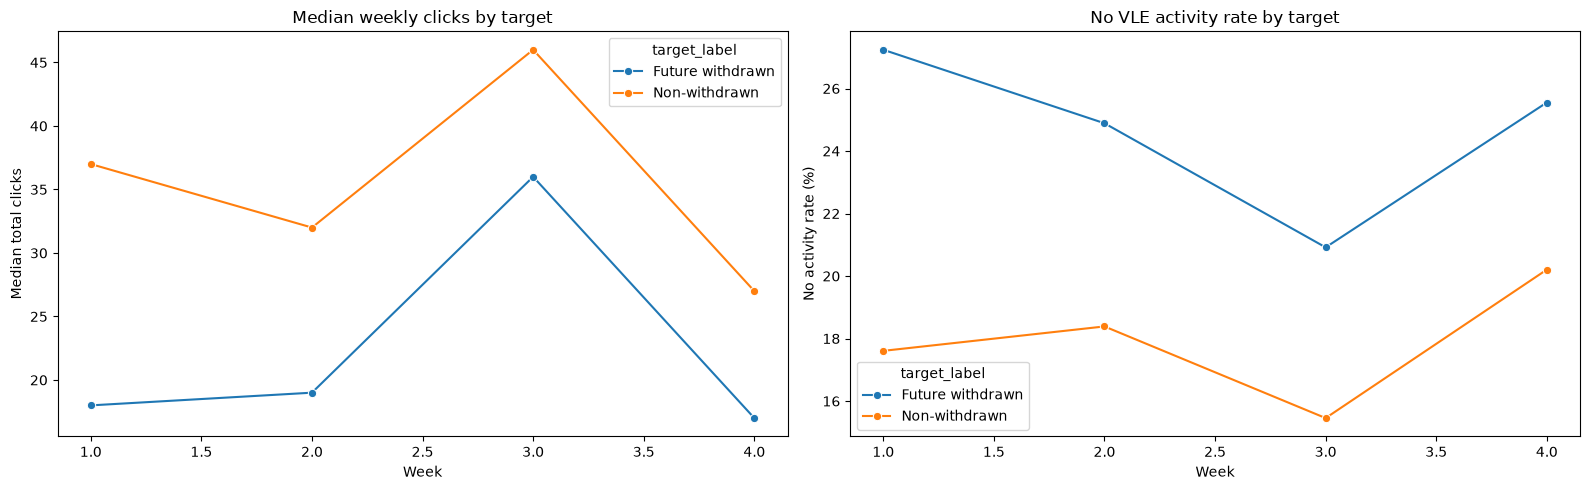

In [14]:
# 해당 주차 VLE 활동이 전혀 없는지 표시
eligible_grid["no_vle_activity"] = (
    eligible_grid["total_clicks"] == 0
).astype(int)

weekly_target_summary = (
    eligible_grid
    .groupby(
        ["week_index", "target_label"],
        observed=True,
        as_index=False
    )
    .agg(
        student_course_count=("id_student", "size"),
        median_total_clicks=("total_clicks", "median"),
        mean_total_clicks=("total_clicks", "mean"),
        median_active_days=("active_days", "median"),
        median_unique_sites=("unique_sites", "median"),
        no_activity_rate_pct=(
            "no_vle_activity",
            lambda values: values.mean() * 100
        )
    )
)

print("===== Target별 주차 VLE 행동 요약 =====")
display(weekly_target_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 주차별 클릭 중앙값
sns.lineplot(
    data=weekly_target_summary,
    x="week_index",
    y="median_total_clicks",
    hue="target_label",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Median weekly clicks by target")
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Median total clicks")

# 주차별 무활동 비율
sns.lineplot(
    data=weekly_target_summary,
    x="week_index",
    y="no_activity_rate_pct",
    hue="target_label",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("No VLE activity rate by target")
axes[1].set_xlabel("Week")
axes[1].set_ylabel("No activity rate (%)")

plt.tight_layout()
plt.show()

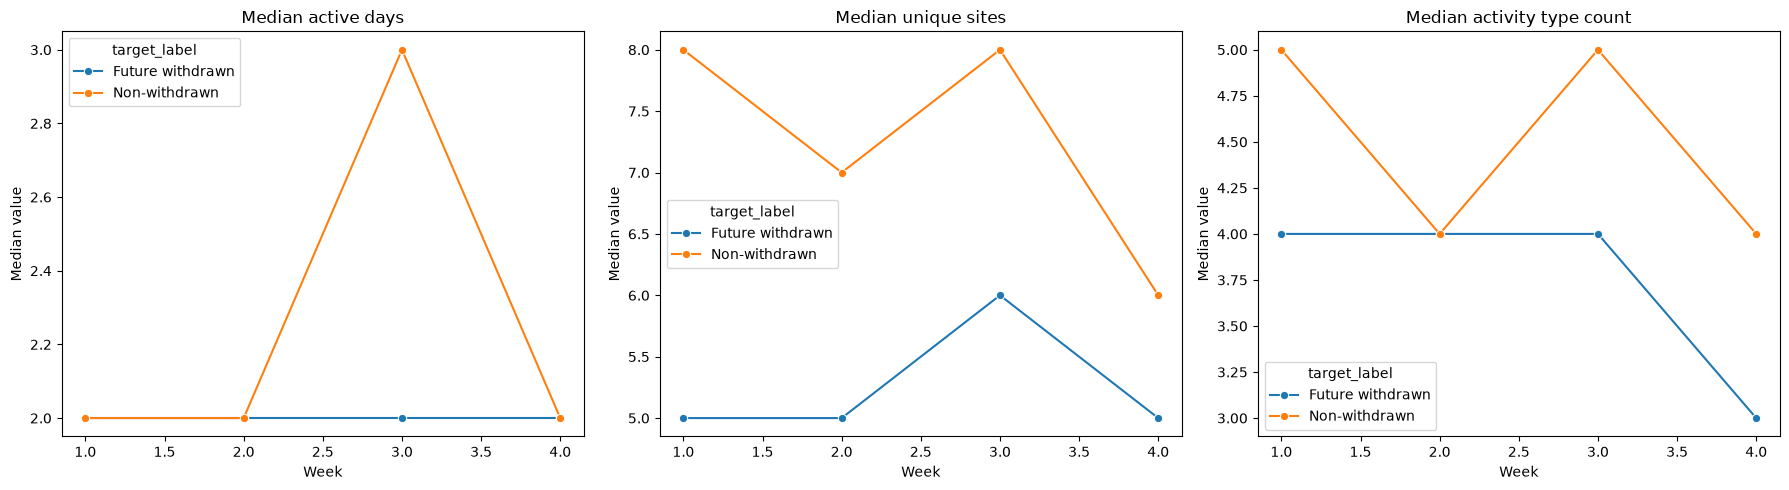

,week_index,target_label,active_days,unique_sites,activity_type_count
0,1,Future withdrawn,2.0,5.0,4.0
1,1,Non-withdrawn,2.0,8.0,5.0
2,2,Future withdrawn,2.0,5.0,4.0
3,2,Non-withdrawn,2.0,7.0,4.0
4,3,Future withdrawn,2.0,6.0,4.0
5,3,Non-withdrawn,3.0,8.0,5.0
6,4,Future withdrawn,2.0,5.0,3.0
7,4,Non-withdrawn,2.0,6.0,4.0


In [15]:
behavior_features = [
    "active_days",
    "unique_sites",
    "activity_type_count"
]

behavior_summary = (
    eligible_grid
    .groupby(
        ["week_index", "target_label"],
        observed=True,
        as_index=False
    )[behavior_features]
    .median()
)

behavior_long = behavior_summary.melt(
    id_vars=[
        "week_index",
        "target_label"
    ],
    value_vars=behavior_features,
    var_name="feature",
    value_name="median_value"
)

feature_titles = {
    "active_days": "Median active days",
    "unique_sites": "Median unique sites",
    "activity_type_count": "Median activity type count"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, feature in zip(
    axes,
    behavior_features
):
    feature_data = behavior_long.loc[
        behavior_long["feature"] == feature
    ]

    sns.lineplot(
        data=feature_data,
        x="week_index",
        y="median_value",
        hue="target_label",
        marker="o",
        ax=axis
    )

    axis.set_title(feature_titles[feature])
    axis.set_xlabel("Week")
    axis.set_ylabel("Median value")

plt.tight_layout()
plt.show()

display(behavior_summary)

,code_module,target_label,student_course_count,median_total_clicks,mean_total_clicks,median_active_days,median_unique_sites,median_activity_type_count,no_activity_rate_pct
0,AAA,Future withdrawn,105,56.0,93.30,3.0,9.0,5.0,10.48
1,AAA,Non-withdrawn,619,55.0,89.72,3.0,9.0,5.0,12.28
2,BBB,Future withdrawn,1274,8.0,31.01,1.0,4.0,3.0,39.40
3,BBB,Non-withdrawn,5481,23.0,46.78,2.0,6.0,4.0,23.28
4,CCC,Future withdrawn,1405,12.0,41.53,2.0,4.0,3.0,25.48
5,CCC,Non-withdrawn,2455,29.0,73.46,2.0,7.0,4.0,15.72
6,DDD,Future withdrawn,1555,23.0,42.40,2.0,6.0,4.0,21.86
7,DDD,Non-withdrawn,4010,43.0,62.76,3.0,10.0,6.0,12.74
8,EEE,Future withdrawn,468,9.0,39.87,1.0,3.0,2.0,31.62
9,EEE,Non-withdrawn,2207,43.0,76.41,3.0,7.0,4.0,14.14


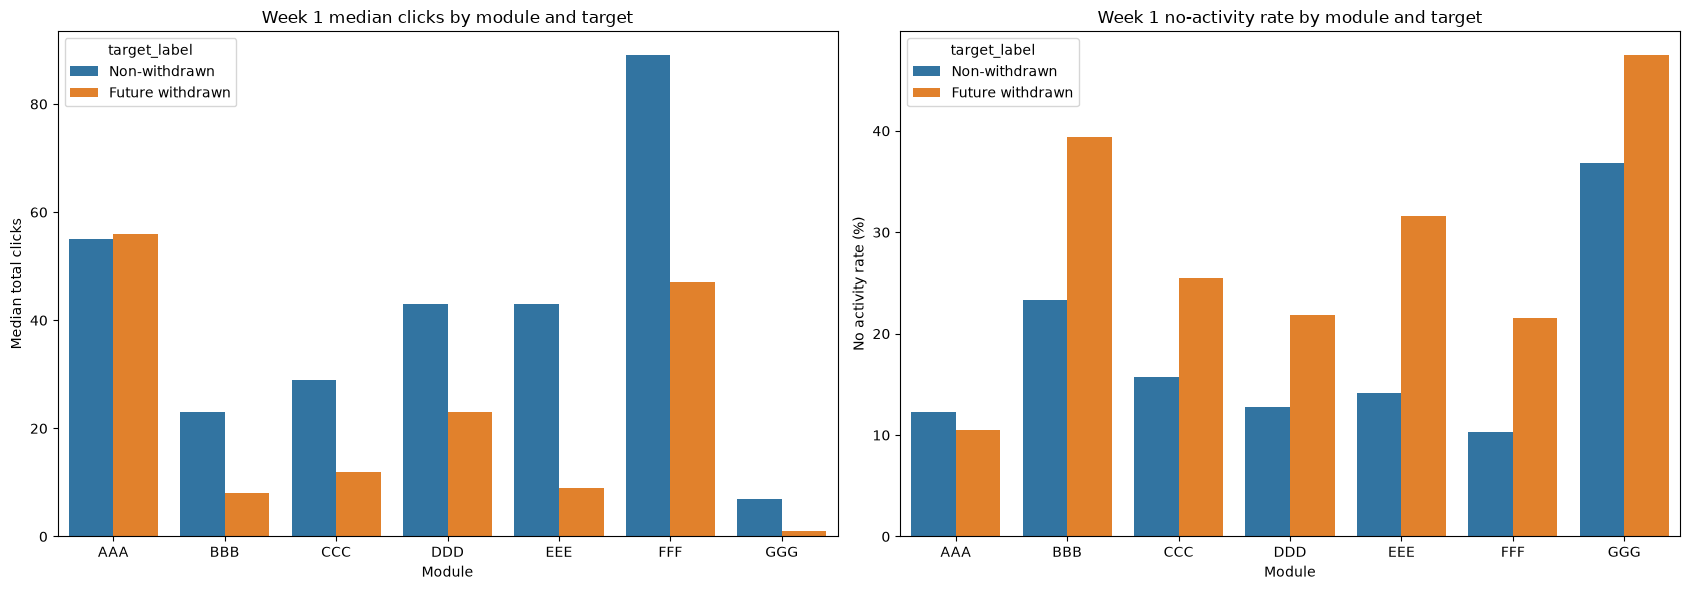

In [16]:
week1_eligible = eligible_grid.loc[
    eligible_grid["week_index"] == 1
].copy()

module_week1_summary = (
    week1_eligible
    .groupby(
        ["code_module", "target_label"],
        observed=True,
        as_index=False
    )
    .agg(
        student_course_count=("id_student", "size"),
        median_total_clicks=("total_clicks", "median"),
        mean_total_clicks=("total_clicks", "mean"),
        median_active_days=("active_days", "median"),
        median_unique_sites=("unique_sites", "median"),
        median_activity_type_count=(
            "activity_type_count",
            "median"
        ),
        no_activity_rate_pct=(
            "no_vle_activity",
            lambda values: values.mean() * 100
        )
    )
)

display(
    module_week1_summary
    .sort_values(
        ["code_module", "target_label"]
    )
    .round(2)
)

TARGET_ORDER = [
    "Non-withdrawn",
    "Future withdrawn"
]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.barplot(
    data=module_week1_summary,
    x="code_module",
    y="median_total_clicks",
    hue="target_label",
    hue_order=TARGET_ORDER,
    ax=axes[0]
)

axes[0].set_title("Week 1 median clicks by module and target")
axes[0].set_xlabel("Module")
axes[0].set_ylabel("Median total clicks")

sns.barplot(
    data=module_week1_summary,
    x="code_module",
    y="no_activity_rate_pct",
    hue="target_label",
    hue_order=TARGET_ORDER,
    ax=axes[1]
)

axes[1].set_title("Week 1 no-activity rate by module and target")
axes[1].set_xlabel("Module")
axes[1].set_ylabel("No activity rate (%)")

plt.tight_layout()
plt.show()

In [20]:
student_week_grid["registration_week_for_model"] = np.where(
    student_week_grid["registration_day_for_model"] <= 0,
    1,
    (
        student_week_grid["registration_day_for_model"] // 7
        + 1
    )
).astype(int)

student_week_grid["is_exposed_week"] = (
    student_week_grid["week_index"]
    >= student_week_grid["registration_week_for_model"]
)

SUM_FEATURE_RENAME = {
    "total_clicks": "cum_total_clicks",
    "interaction_rows": "cum_interaction_rows",
    "active_days": "cum_active_days",
    "unique_sites": "cum_unique_site_week_count",
    "activity_type_count": "cum_activity_type_week_count",
    "forumng_clicks": "cum_forumng_clicks",
    "quiz_clicks": "cum_quiz_clicks",
    "oucontent_clicks": "cum_oucontent_clicks",
    "resource_clicks": "cum_resource_clicks",
    "other_clicks": "cum_other_clicks"
}

In [21]:
snapshots = {}

PRE_COURSE_FEATURES = [
    "pre_course_clicks",
    "pre_course_interaction_rows"
]

for cutoff_week in CANDIDATE_WEEKS:
    # 후보 시점까지 실제 관찰 가능한 주차
    history = student_week_grid.loc[
        (student_week_grid["week_index"] <= cutoff_week)
        & student_week_grid["is_exposed_week"]
    ].copy()

    # 누적 VLE Feature
    cumulative_features = (
        history
        .groupby(
            COHORT_KEYS,
            as_index=False
        )[list(SUM_FEATURE_RENAME.keys())]
        .sum()
        .rename(columns=SUM_FEATURE_RENAME)
    )

    # 실제 관찰 주차와 활동 주차
    exposure_features = (
        history
        .groupby(
            COHORT_KEYS,
            as_index=False
        )
        .agg(
            observed_weeks=("week_index", "nunique"),
            active_weeks=("has_vle_record", "sum")
        )
    )

    # 해당 시점에 아직 수강 중인 학생
    snapshot_base = (
        eligible_grid.loc[
            eligible_grid["week_index"] == cutoff_week,
            COHORT_KEYS + [
                "target",
                "final_result",
                "date_registration",
                "date_unregistration",
                "module_presentation_length"
            ]
        ]
        .drop_duplicates(COHORT_KEYS)
    )

    snapshot = (
        snapshot_base
        .merge(
            cumulative_features,
            on=COHORT_KEYS,
            how="left",
            validate="one_to_one"
        )
        .merge(
            exposure_features,
            on=COHORT_KEYS,
            how="left",
            validate="one_to_one"
        )
        .merge(
            vle_pre,
            on=COHORT_KEYS,
            how="left",
            validate="one_to_one"
        )
    )

    # 개강 전 활동 기록이 없으면 0
    snapshot[PRE_COURSE_FEATURES] = (
        snapshot[PRE_COURSE_FEATURES]
        .fillna(0)
    )

    # 무활동 주차와 활동 주차 비율
    snapshot["inactive_weeks"] = (
        snapshot["observed_weeks"]
        - snapshot["active_weeks"]
    )

    snapshot["active_week_rate"] = (
        snapshot["active_weeks"]
        / snapshot["observed_weeks"]
    )

    # 누적 평균 Feature 재계산
    snapshot["cum_avg_clicks_per_active_day"] = (
        snapshot["cum_total_clicks"]
        / snapshot["cum_active_days"].replace(0, np.nan)
    ).fillna(0)

    snapshot["cum_avg_clicks_per_site_week"] = (
        snapshot["cum_total_clicks"]
        / snapshot[
            "cum_unique_site_week_count"
        ].replace(0, np.nan)
    ).fillna(0)

    snapshot["cutoff_week"] = cutoff_week

    snapshots[cutoff_week] = snapshot

for cutoff_week, snapshot in snapshots.items():
    print(f"\n===== {cutoff_week}주차 Snapshot =====")
    print("행 수:", len(snapshot))
    print(
        "키 중복:",
        snapshot.duplicated(COHORT_KEYS).sum()
    )
    print(
        "전체 결측치:",
        snapshot.isna().sum().sum()
    )
    print("Target 분포:")
    print(snapshot["target"].value_counts().sort_index())


===== 1주차 Snapshot =====
행 수: 29018
키 중복: 0
전체 결측치: 22366
Target 분포:
target
0    22366
1     6652
Name: count, dtype: int64

===== 2주차 Snapshot =====
행 수: 27984
키 중복: 0
전체 결측치: 22393
Target 분포:
target
0    22395
1     5589
Name: count, dtype: int64

===== 4주차 Snapshot =====
행 수: 27449
키 중복: 0
전체 결측치: 22422
Target 분포:
target
0    22424
1     5025
Name: count, dtype: int64


In [22]:
CURRENT_SOURCE_FEATURES = [
    "total_clicks",
    "interaction_rows",
    "active_days",
    "unique_sites",
    "activity_type_count",
    "forumng_clicks",
    "quiz_clicks",
    "oucontent_clicks",
    "resource_clicks",
    "other_clicks",
    "has_vle_record"
]

PREVIOUS_SOURCE_FEATURES = [
    "total_clicks",
    "active_days",
    "unique_sites"
]

for cutoff_week in CANDIDATE_WEEKS:
    snapshot = snapshots[cutoff_week].copy()

    # 현재 주차 Feature
    current_features = (
        student_week_grid.loc[
            student_week_grid["week_index"] == cutoff_week,
            COHORT_KEYS + CURRENT_SOURCE_FEATURES
        ]
        .rename(
            columns={
                column: f"current_{column}"
                for column in CURRENT_SOURCE_FEATURES
            }
        )
    )

    # 직전 주차 Feature
    if cutoff_week == 1:
        previous_features = current_features[
            COHORT_KEYS
        ].copy()

        for column in PREVIOUS_SOURCE_FEATURES:
            previous_features[
                f"previous_{column}"
            ] = 0
    else:
        previous_features = (
            student_week_grid.loc[
                student_week_grid["week_index"]
                == cutoff_week - 1,
                COHORT_KEYS + PREVIOUS_SOURCE_FEATURES
            ]
            .rename(
                columns={
                    column: f"previous_{column}"
                    for column in PREVIOUS_SOURCE_FEATURES
                }
            )
        )

    # 마지막 활동 주차
    active_history = student_week_grid.loc[
        (student_week_grid["week_index"] <= cutoff_week)
        & student_week_grid["is_exposed_week"]
        & student_week_grid["has_vle_record"].eq(1)
    ]

    last_activity = (
        active_history
        .groupby(
            COHORT_KEYS,
            as_index=False
        )
        .agg(
            last_active_week=("week_index", "max")
        )
    )

    snapshot = (
        snapshot
        .merge(
            current_features,
            on=COHORT_KEYS,
            how="left",
            validate="one_to_one"
        )
        .merge(
            previous_features,
            on=COHORT_KEYS,
            how="left",
            validate="one_to_one"
        )
        .merge(
            last_activity,
            on=COHORT_KEYS,
            how="left",
            validate="one_to_one"
        )
    )

    # 한 번도 활동하지 않은 학생은 0
    snapshot["last_active_week"] = (
        snapshot["last_active_week"]
        .fillna(0)
        .astype(int)
    )

    snapshot["weeks_since_last_activity"] = np.where(
        snapshot["last_active_week"].eq(0),
        snapshot["observed_weeks"],
        cutoff_week - snapshot["last_active_week"]
    ).astype(int)

    snapshot["current_no_activity"] = (
        1 - snapshot["current_has_vle_record"]
    )

    # 직전 주차 대비 변화
    snapshot["click_change"] = (
        snapshot["current_total_clicks"]
        - snapshot["previous_total_clicks"]
    )

    snapshot["click_change_rate"] = (
        snapshot["click_change"]
        / (
            snapshot["previous_total_clicks"]
            + 1
        )
    )

    snapshot["active_days_change"] = (
        snapshot["current_active_days"]
        - snapshot["previous_active_days"]
    )

    snapshot["unique_sites_change"] = (
        snapshot["current_unique_sites"]
        - snapshot["previous_unique_sites"]
    )

    # 누적 활동 유형별 비중
    cumulative_activity_columns = [
        "cum_forumng_clicks",
        "cum_quiz_clicks",
        "cum_oucontent_clicks",
        "cum_resource_clicks",
        "cum_other_clicks"
    ]

    for column in cumulative_activity_columns:
        share_name = column.replace(
            "_clicks",
            "_share"
        )

        snapshot[share_name] = (
            snapshot[column]
            / snapshot["cum_total_clicks"].replace(
                0,
                np.nan
            )
        ).fillna(0)

    # 클릭 수 분포의 심한 치우침 완화용
    snapshot["log1p_cum_total_clicks"] = np.log1p(
        snapshot["cum_total_clicks"]
    )

    snapshot["log1p_current_total_clicks"] = np.log1p(
        snapshot["current_total_clicks"]
    )

    snapshot["log1p_pre_course_clicks"] = np.log1p(
        snapshot["pre_course_clicks"]
    )

    snapshots[cutoff_week] = snapshot

CHECK_FEATURES = [
    "cum_total_clicks",
    "cum_active_days",
    "active_weeks",
    "inactive_weeks",
    "active_week_rate",
    "current_total_clicks",
    "previous_total_clicks",
    "click_change",
    "click_change_rate",
    "current_no_activity",
    "last_active_week",
    "weeks_since_last_activity",
    "pre_course_clicks",
    "log1p_cum_total_clicks"
]

for cutoff_week, snapshot in snapshots.items():
    print(f"\n===== {cutoff_week}주차 추가 Feature 점검 =====")
    print(
        "Feature 결측치:",
        snapshot[CHECK_FEATURES]
        .isna()
        .sum()
        .sum()
    )
    print(
        "키 중복:",
        snapshot.duplicated(COHORT_KEYS).sum()
    )

    display(
        snapshot[
            COHORT_KEYS
            + ["target", "cutoff_week"]
            + CHECK_FEATURES
        ].head()
    )


===== 1주차 추가 Feature 점검 =====
Feature 결측치: 0
키 중복: 0


,code_module,code_presentation,id_student,target,cutoff_week,cum_total_clicks,cum_active_days,active_weeks,inactive_weeks,active_week_rate,current_total_clicks,previous_total_clicks,click_change,click_change_rate,current_no_activity,last_active_week,weeks_since_last_activity,pre_course_clicks,log1p_cum_total_clicks
0,AAA,2013J,11391,0,1,183.0,4.0,1,0,1.0,183.0,0,183.0,183.0,0,1,0,98.0,5.214936
1,AAA,2013J,28400,0,1,175.0,5.0,1,0,1.0,175.0,0,175.0,175.0,0,1,0,215.0,5.170484
2,AAA,2013J,30268,1,1,107.0,3.0,1,0,1.0,107.0,0,107.0,107.0,0,1,0,102.0,4.682131
3,AAA,2013J,31604,0,1,22.0,1.0,1,0,1.0,22.0,0,22.0,22.0,0,1,0,169.0,3.135494
4,AAA,2013J,32885,0,1,61.0,5.0,1,0,1.0,61.0,0,61.0,61.0,0,1,0,295.0,4.127134



===== 2주차 추가 Feature 점검 =====
Feature 결측치: 0
키 중복: 0


,code_module,code_presentation,id_student,target,cutoff_week,cum_total_clicks,cum_active_days,active_weeks,inactive_weeks,active_week_rate,current_total_clicks,previous_total_clicks,click_change,click_change_rate,current_no_activity,last_active_week,weeks_since_last_activity,pre_course_clicks,log1p_cum_total_clicks
0,AAA,2013J,11391,0,2,203.0,5.0,2,0,1.0,20.0,183.0,-163.0,-0.885870,0,2,0,98.0,5.318120
1,AAA,2013J,28400,0,2,241.0,7.0,2,0,1.0,66.0,175.0,-109.0,-0.619318,0,2,0,215.0,5.488938
2,AAA,2013J,31604,0,2,176.0,7.0,2,0,1.0,154.0,22.0,132.0,5.739130,0,2,0,169.0,5.176150
3,AAA,2013J,32885,0,2,177.0,9.0,2,0,1.0,116.0,61.0,55.0,0.887097,0,2,0,295.0,5.181784
4,AAA,2013J,38053,0,2,276.0,12.0,2,0,1.0,141.0,135.0,6.0,0.044118,0,2,0,277.0,5.624018



===== 4주차 추가 Feature 점검 =====
Feature 결측치: 0
키 중복: 0


,code_module,code_presentation,id_student,target,cutoff_week,cum_total_clicks,cum_active_days,active_weeks,inactive_weeks,active_week_rate,current_total_clicks,previous_total_clicks,click_change,click_change_rate,current_no_activity,last_active_week,weeks_since_last_activity,pre_course_clicks,log1p_cum_total_clicks
0,AAA,2013J,11391,0,4,303.0,7.0,3,1,0.75,0.0,100.0,-100.0,-0.990099,1,3,1,98.0,5.717028
1,AAA,2013J,28400,0,4,335.0,11.0,4,0,1.00,57.0,37.0,20.0,0.526316,0,4,0,215.0,5.817111
2,AAA,2013J,31604,0,4,309.0,16.0,4,0,1.00,25.0,108.0,-83.0,-0.761468,0,4,0,169.0,5.736572
3,AAA,2013J,32885,0,4,272.0,16.0,4,0,1.00,58.0,37.0,21.0,0.552632,0,4,0,295.0,5.609472
4,AAA,2013J,38053,0,4,450.0,23.0,4,0,1.00,39.0,135.0,-96.0,-0.705882,0,4,0,277.0,6.111467


,cutoff_week,target_label,student_course_count,median_cum_total_clicks,median_current_total_clicks,median_cum_active_days,median_cum_unique_sites,current_no_activity_rate_pct,median_weeks_since_last_activity
0,1,Future withdrawn,6652,18.0,18.0,2.0,5.0,27.24,0.0
1,1,Non-withdrawn,22366,37.0,37.0,2.0,8.0,17.61,0.0
2,2,Future withdrawn,5589,53.0,19.0,4.0,12.0,24.89,0.0
3,2,Non-withdrawn,22395,80.0,32.0,5.0,16.0,18.39,0.0
4,4,Future withdrawn,5025,143.0,17.0,8.0,27.0,25.55,0.0
5,4,Non-withdrawn,22424,184.0,27.0,10.0,31.0,20.21,0.0


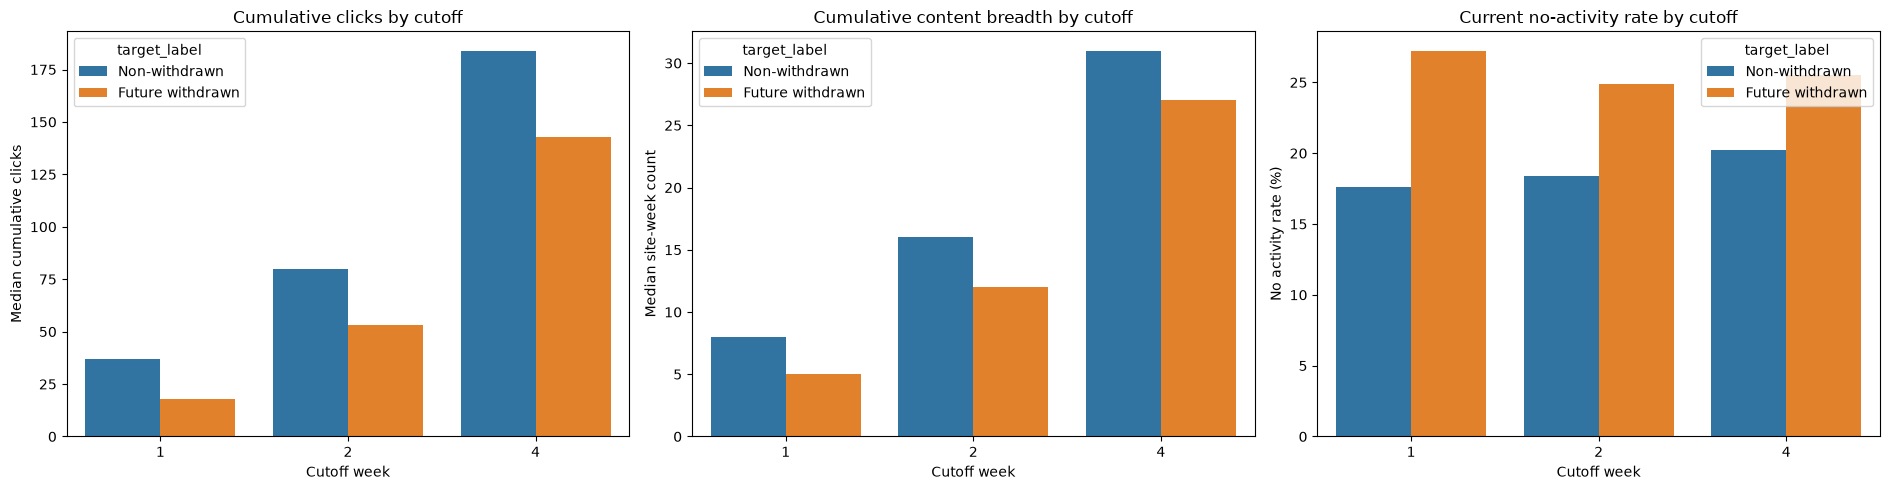

In [23]:
snapshot_summary_parts = []

for cutoff_week, snapshot in snapshots.items():
    snapshot_eda = snapshot.copy()

    snapshot_eda["target_label"] = (
        snapshot_eda["target"]
        .map({
            0: "Non-withdrawn",
            1: "Future withdrawn"
        })
    )

    summary = (
        snapshot_eda
        .groupby(
            "target_label",
            observed=True,
            as_index=False
        )
        .agg(
            student_course_count=("id_student", "size"),
            median_cum_total_clicks=(
                "cum_total_clicks",
                "median"
            ),
            median_current_total_clicks=(
                "current_total_clicks",
                "median"
            ),
            median_cum_active_days=(
                "cum_active_days",
                "median"
            ),
            median_cum_unique_sites=(
                "cum_unique_site_week_count",
                "median"
            ),
            median_active_week_rate=(
                "active_week_rate",
                "median"
            ),
            current_no_activity_rate_pct=(
                "current_no_activity",
                lambda values: values.mean() * 100
            ),
            median_weeks_since_last_activity=(
                "weeks_since_last_activity",
                "median"
            )
        )
    )

    summary["cutoff_week"] = cutoff_week
    snapshot_summary_parts.append(summary)

snapshot_target_summary = pd.concat(
    snapshot_summary_parts,
    ignore_index=True
)

display(
    snapshot_target_summary[
        [
            "cutoff_week",
            "target_label",
            "student_course_count",
            "median_cum_total_clicks",
            "median_current_total_clicks",
            "median_cum_active_days",
            "median_cum_unique_sites",
            "current_no_activity_rate_pct",
            "median_weeks_since_last_activity"
        ]
    ].round(2)
)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.barplot(
    data=snapshot_target_summary,
    x="cutoff_week",
    y="median_cum_total_clicks",
    hue="target_label",
    hue_order=TARGET_ORDER,
    ax=axes[0]
)

axes[0].set_title("Cumulative clicks by cutoff")
axes[0].set_xlabel("Cutoff week")
axes[0].set_ylabel("Median cumulative clicks")

sns.barplot(
    data=snapshot_target_summary,
    x="cutoff_week",
    y="median_cum_unique_sites",
    hue="target_label",
    hue_order=TARGET_ORDER,
    ax=axes[1]
)

axes[1].set_title("Cumulative content breadth by cutoff")
axes[1].set_xlabel("Cutoff week")
axes[1].set_ylabel("Median site-week count")

sns.barplot(
    data=snapshot_target_summary,
    x="cutoff_week",
    y="current_no_activity_rate_pct",
    hue="target_label",
    hue_order=TARGET_ORDER,
    ax=axes[2]
)

axes[2].set_title("Current no-activity rate by cutoff")
axes[2].set_xlabel("Cutoff week")
axes[2].set_ylabel("No activity rate (%)")

plt.tight_layout()
plt.show()

In [24]:
SAFE_BASELINE_COLUMNS = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "imd_band_missing",
    "age_band",
    "num_of_prev_attempts",
    "studied_credits",
    "disability",
    "date_registration_missing"
]

baseline_info = (
    cohort[
        COHORT_KEYS + SAFE_BASELINE_COLUMNS
    ]
    .drop_duplicates(COHORT_KEYS)
)

print(
    "기본정보 키 중복:",
    baseline_info.duplicated(COHORT_KEYS).sum()
)
print(
    "기본정보 결측치:",
    baseline_info[
        SAFE_BASELINE_COLUMNS
    ].isna().sum().sum()
)

RELATIVE_FEATURES = [
    "cum_total_clicks",
    "current_total_clicks",
    "cum_active_days",
    "cum_unique_site_week_count"
]

COURSE_CONTEXT_KEYS = [
    "code_module",
    "code_presentation"
]

for cutoff_week in CANDIDATE_WEEKS:
    snapshot = snapshots[cutoff_week].copy()

    snapshot = snapshot.merge(
        baseline_info,
        on=COHORT_KEYS,
        how="left",
        validate="one_to_one"
    )

    # 등록 시점 Feature
    registration_day = (
        snapshot["date_registration"]
        .fillna(0)
    )

    snapshot["registered_after_start"] = (
        registration_day > 0
    ).astype(int)

    snapshot["registration_lead_days"] = (
        -registration_day
    ).clip(lower=0)

    snapshot["late_registration_days"] = (
        registration_day
    ).clip(lower=0)

    # 같은 과목·운영 회차 안에서의 상대적 활동량
    for feature in RELATIVE_FEATURES:
        course_median = (
            snapshot
            .groupby(COURSE_CONTEXT_KEYS)[feature]
            .transform("median")
        )

        snapshot[
            f"{feature}_vs_course_median"
        ] = (
            (snapshot[feature] + 1)
            / (course_median + 1)
        )

        snapshot[
            f"{feature}_course_percentile"
        ] = (
            snapshot
            .groupby(COURSE_CONTEXT_KEYS)[feature]
            .rank(
                method="average",
                pct=True
            )
        )

    snapshots[cutoff_week] = snapshot

NEW_FEATURES = (
    SAFE_BASELINE_COLUMNS
    + [
        "registered_after_start",
        "registration_lead_days",
        "late_registration_days"
    ]
    + [
        f"{feature}_vs_course_median"
        for feature in RELATIVE_FEATURES
    ]
    + [
        f"{feature}_course_percentile"
        for feature in RELATIVE_FEATURES
    ]
)

for cutoff_week, snapshot in snapshots.items():
    print(f"\n===== {cutoff_week}주차 기본·상대 Feature =====")
    print(
        "추가 Feature 결측치:",
        snapshot[NEW_FEATURES]
        .isna()
        .sum()
        .sum()
    )
    print(
        "Target 비율:",
        f"{snapshot['target'].mean() * 100:.2f}%"
    )

기본정보 키 중복: 0
기본정보 결측치: 0

===== 1주차 기본·상대 Feature =====
추가 Feature 결측치: 0
Target 비율: 22.92%

===== 2주차 기본·상대 Feature =====
추가 Feature 결측치: 0
Target 비율: 19.97%

===== 4주차 기본·상대 Feature =====
추가 Feature 결측치: 0
Target 비율: 18.31%


In [25]:
DROP_FROM_MODEL = [
    "final_result",
    "date_registration",
    "date_unregistration"
]

exported_snapshots = {}

for cutoff_week, snapshot in snapshots.items():
    model_snapshot = snapshot.drop(
        columns=DROP_FROM_MODEL,
        errors="ignore"
    ).copy()

    # 주요 컬럼을 앞으로 정렬
    first_columns = (
        COHORT_KEYS
        + [
            "cutoff_week",
            "target"
        ]
    )

    remaining_columns = [
        column
        for column in model_snapshot.columns
        if column not in first_columns
    ]

    model_snapshot = model_snapshot[
        first_columns + remaining_columns
    ]

    output_path = (
        INTERIM_DIR
        / f"vle_snapshot_week_{cutoff_week}.csv"
    )

    model_snapshot.to_csv(
        output_path,
        index=False
    )

    exported_snapshots[cutoff_week] = model_snapshot

    print(f"\n===== {cutoff_week}주차 저장 =====")
    print("파일:", output_path.name)
    print("크기:", model_snapshot.shape)
    print(
        "키 중복:",
        model_snapshot.duplicated(
            COHORT_KEYS
        ).sum()
    )
    print(
        "전체 결측치:",
        model_snapshot.isna().sum().sum()
    )
    print(
        "파일 용량:",
        f"{output_path.stat().st_size / 1024**2:.1f} MB"
    )

LEAKAGE_COLUMNS = [
    "final_result",
    "date_unregistration",
    "unregister_yn",
    "pre_course_unregister_yn",
    "unregister_week"
]

for cutoff_week, model_snapshot in exported_snapshots.items():
    remaining_leakage = [
        column
        for column in LEAKAGE_COLUMNS
        if column in model_snapshot.columns
    ]

    print(
        f"{cutoff_week}주차 누출 컬럼:",
        remaining_leakage
    )



===== 1주차 저장 =====
파일: vle_snapshot_week_1.csv
크기: (29018, 74)
키 중복: 0
전체 결측치: 0
파일 용량: 13.3 MB

===== 2주차 저장 =====
파일: vle_snapshot_week_2.csv
크기: (27984, 74)
키 중복: 0
전체 결측치: 0
파일 용량: 14.1 MB

===== 4주차 저장 =====
파일: vle_snapshot_week_4.csv
크기: (27449, 74)
키 중복: 0
전체 결측치: 0
파일 용량: 14.3 MB
1주차 누출 컬럼: []
2주차 누출 컬럼: []
4주차 누출 컬럼: []


### 저장위치

data/interim/vle_snapshot_week_1.csv

data/interim/vle_snapshot_week_2.csv

data/interim/vle_snapshot_week_4.csv

## Target별 VLE 전처리·EDA 결론

### 1. 전체 학생 명단과 VLE 연결

- 전체 학생·강좌 수강 건수는 32,593건이다.
- 개강 후 VLE 기록이 있는 수강 건수는 28,500건이다.
- 개강 후 VLE 기록이 없는 4,093건은 삭제하지 않고 활동값을 0으로 처리했다.
- VLE 데이터와 전체 학생 명단 간 연결 실패는 0건이었다.

### 2. 예측 대상 정의

- 개강 전 이탈, 이탈 날짜 없음, 강좌 종료 후 비정상 이탈 등 2,770건은 이탈 시점 분석에서 제외했다.
- 각 후보 주차 종료 시점에 이미 이탈한 학생은 예측 대상에서 제외했다.
- Target 1은 해당 시점에 수강 중이지만 이후 최종 이탈하는 학생으로 정의했다.

### 3. 이탈·비이탈 VLE 행동 차이

- 1주차 미래 이탈자의 클릭 중앙값은 18회, 비이탈자는 37회였다.
- 1주차부터 미래 이탈자의 무활동 비율이 더 높았다.
- 미래 이탈자는 이용한 콘텐츠 수와 활동 유형 다양성도 전반적으로 낮았다.
- 따라서 이탈이 집중되는 2주차 이전인 1주차부터 행동 기반 위험 신호를 확인할 수 있었다.

### 4. 과목별 차이

- 대부분 과목에서 미래 이탈자의 클릭량이 낮고 무활동 비율이 높았다.
- AAA는 다른 과목과 다른 행동 패턴을 보여 절대 클릭 기준만으로 위험 여부를 판단하기 어렵다.
- GGG는 두 집단 모두 기본 무활동 비율이 높았다.
- 최종 모델에는 과목 정보와 과목 내 활동 백분위·중앙값 대비 비율을 포함해야 한다.

### 5. 후보 주차 Snapshot

- 1주차: 29,018건, 미래 이탈자 6,652건
- 2주차: 27,984건, 미래 이탈자 5,589건
- 4주차: 27,449건, 미래 이탈자 5,025건
- 누적 클릭, 활동일, 콘텐츠 범위, 활동 유형, 무활동 주차, 최근 활동, 직전 주차 대비 증감 Feature를 생성했다.
- 개강 전 VLE Feature와 학생 기본정보를 연결했다.
- 이탈 결과를 직접 알려주는 누출 컬럼은 저장 전에 제거했다.

### 6. 다음 단계

- 팀원의 평가 데이터 전처리 결과를 학생·강좌·후보 주차 단위로 집계한다.
- VLE Snapshot과 평가 Feature를 Left Join한다.
- 최종 학습 데이터를 data/processed에 저장한다.
- 1·2·4주차 모델의 Recall과 예측 가능 대상 규모를 비교해 골든타임을 선정한다.